# PRÁCTICA TEMA 9. ENFERMEDADES CARDIOVASCULARES CON REDES NEURONALES

Carga del csv y librerías

In [1]:
import pandas as pd 
import numpy as np 

datos = pd.read_csv("historial_clinico.csv")
df = pd.DataFrame(datos)
df

,edad,creatinina_fosfocinasa,diabetes,sangre_contraccion,plaquetas,creatinina,sodio,seguimiento,fallecimiento,anemia,tension,sexo,fumador
0,75,582,No,20,265000.00,1.9,130,4,1,No,muy alta,Hombre,ocasional
1,55,7861,No,38,263358.03,1.1,136,6,1,No,ligeramente alta,Hombre,ocasional
2,65,146,No,20,162000.00,1.3,129,7,1,No,ligeramente alta,Hombre,>2 paquetes/día
3,50,111,No,20,210000.00,1.9,137,7,1,Si,ligeramente alta,Hombre,ocasional
4,65,160,Sí,20,327000.00,2.7,116,8,1,Si,ligeramente alta,Mujer,ocasional
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62,61,Sí,38,155000.00,1.1,143,270,0,0,alta,masculino,sí
295,55,1820,No,38,270000.00,1.2,139,271,0,0,normal,femenino,no
296,45,2060,Sí,60,742000.00,0.8,138,278,0,0,normal,femenino,no
297,45,2413,No,38,140000.00,1.4,140,280,0,0,normal,masculino,sí


# AED 

In [2]:
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   edad                    299 non-null    int64  
 1   creatinina_fosfocinasa  299 non-null    int64  
 2   diabetes                299 non-null    object 
 3   sangre_contraccion      299 non-null    int64  
 4   plaquetas               299 non-null    float64
 5   creatinina              299 non-null    float64
 6   sodio                   299 non-null    int64  
 7   seguimiento             299 non-null    int64  
 8   fallecimiento           299 non-null    int64  
 9   anemia                  298 non-null    object 
 10  tension                 299 non-null    object 
 11  sexo                    299 non-null    object 
 12  fumador                 299 non-null    object 
dtypes: float64(2), int64(6), object(5)
memory usage: 30.5+ KB
edad                      0
creatinin

Observamos un dato nulo en la columna "anemia", antes de tomar la decisión de borrarlo o no, vamos a comprobar los demás valores de las columnas.

In [3]:
for c in df.columns:
    print(df[c].value_counts())
    print("================")

edad
60    35
50    27
65    26
70    25
45    19
55    17
75    11
58    10
53    10
63     8
42     7
40     7
72     7
80     7
85     6
52     5
68     5
62     5
49     4
61     4
59     4
73     4
51     4
64     3
46     3
69     3
82     3
90     3
66     2
78     2
54     2
77     2
57     2
44     2
67     2
95     2
48     2
43     1
86     1
81     1
79     1
41     1
94     1
87     1
47     1
56     1
Name: count, dtype: int64
creatinina_fosfocinasa
582     47
66       4
129      4
231      3
69       3
        ..
748      1
1876     1
936      1
292      1
2413     1
Name: count, Length: 208, dtype: int64
diabetes
No    174
Sí    125
Name: count, dtype: int64
sangre_contraccion
35    49
38    40
40    37
25    36
30    34
60    31
50    21
45    20
20    18
55     3
15     2
62     2
17     2
65     1
14     1
80     1
70     1
Name: count, dtype: int64
plaquetas
263358.03    25
221000.00     4
279000.00     4
271000.00     4
305000.00     4
             ..
227000.00    

Observamos que el dataframe no se encuentra aún listo para entrenar al modelo, vamos a proceder a limpiar los datos.

Columna Anemia. Reemplazaremos los valores "no" y "No" a 0, mientras que "Si" y "Sí" lo pasaremos a 1

In [4]:
#Para caso de no tener anemia
df["anemia"] = df["anemia"].replace("no", 0)
df["anemia"] = df["anemia"].replace("No", 0)
df["anemia"] = df["anemia"].replace("0", 0) #Para que lo detecte como int y no string


#Para el caso de sí tener anemia
df["anemia"] = df["anemia"].replace("Si", 1)
df["anemia"] = df["anemia"].replace("Sí", 1)
df["anemia"] = df["anemia"].replace("1", 1)


df["anemia"].value_counts()


C:\Users\David\AppData\Local\Temp\ipykernel_16692\2186304341.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["anemia"] = df["anemia"].replace("1", 1)


anemia
0.0    170
1.0    128
Name: count, dtype: int64

In [5]:
df= df.dropna(subset=["anemia"])

In [6]:
df.isna().sum()

edad                      0
creatinina_fosfocinasa    0
diabetes                  0
sangre_contraccion        0
plaquetas                 0
creatinina                0
sodio                     0
seguimiento               0
fallecimiento             0
anemia                    0
tension                   0
sexo                      0
fumador                   0
dtype: int64

Columna "sexo". Realizaremos el mismo proceso que con anemia.

In [7]:
df["sexo"].value_counts()

sexo
Hombre       66
Man          64
masculino    63
Woman        36
femenino     35
Mujer        34
Name: count, dtype: int64

In [8]:
df["sexo"] = df["sexo"].map({
    "Hombre" : 0, 
    "Man" : 0, 
    "masculino":0, 
    "Woman":1, 
    "femenino": 1, 
    "Mujer":1
})


C:\Users\David\AppData\Local\Temp\ipykernel_16692\613659257.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sexo"] = df["sexo"].map({


In [9]:
df["sexo"].value_counts()

sexo
0    193
1    105
Name: count, dtype: int64

In [10]:
df

,edad,creatinina_fosfocinasa,diabetes,sangre_contraccion,plaquetas,creatinina,sodio,seguimiento,fallecimiento,anemia,tension,sexo,fumador
0,75,582,No,20,265000.00,1.9,130,4,1,0.0,muy alta,0,ocasional
1,55,7861,No,38,263358.03,1.1,136,6,1,0.0,ligeramente alta,0,ocasional
2,65,146,No,20,162000.00,1.3,129,7,1,0.0,ligeramente alta,0,>2 paquetes/día
3,50,111,No,20,210000.00,1.9,137,7,1,1.0,ligeramente alta,0,ocasional
4,65,160,Sí,20,327000.00,2.7,116,8,1,1.0,ligeramente alta,1,ocasional
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62,61,Sí,38,155000.00,1.1,143,270,0,0.0,alta,0,sí
295,55,1820,No,38,270000.00,1.2,139,271,0,0.0,normal,1,no
296,45,2060,Sí,60,742000.00,0.8,138,278,0,0.0,normal,1,no
297,45,2413,No,38,140000.00,1.4,140,280,0,0.0,normal,0,sí


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   edad                    298 non-null    int64  
 1   creatinina_fosfocinasa  298 non-null    int64  
 2   diabetes                298 non-null    object 
 3   sangre_contraccion      298 non-null    int64  
 4   plaquetas               298 non-null    float64
 5   creatinina              298 non-null    float64
 6   sodio                   298 non-null    int64  
 7   seguimiento             298 non-null    int64  
 8   fallecimiento           298 non-null    int64  
 9   anemia                  298 non-null    float64
 10  tension                 298 non-null    object 
 11  sexo                    298 non-null    int64  
 12  fumador                 298 non-null    object 
dtypes: float64(3), int64(7), object(3)
memory usage: 32.6+ KB


# Ingeniería de propiedades

In [12]:
for c in df.columns:
    print(df[c].value_counts())
    print("================")

edad
60    35
50    27
65    26
70    25
45    19
55    17
75    11
58    10
53    10
42     7
63     7
40     7
72     7
80     7
85     6
52     5
68     5
62     5
49     4
61     4
59     4
73     4
51     4
64     3
46     3
69     3
82     3
90     3
66     2
78     2
54     2
77     2
57     2
44     2
67     2
95     2
48     2
43     1
86     1
81     1
79     1
41     1
94     1
87     1
47     1
56     1
Name: count, dtype: int64
creatinina_fosfocinasa
582     47
66       4
129      4
231      3
69       3
        ..
328      1
748      1
1876     1
936      1
2413     1
Name: count, Length: 207, dtype: int64
diabetes
No    173
Sí    125
Name: count, dtype: int64
sangre_contraccion
35    49
38    40
40    37
25    36
30    34
60    31
50    21
45    19
20    18
55     3
15     2
62     2
17     2
65     1
14     1
80     1
70     1
Name: count, dtype: int64
plaquetas
263358.03    25
279000.00     4
228000.00     4
226000.00     4
305000.00     4
             ..
252000.00    

In [13]:
#Transformación numérica de la columna "diabetes"
df["diabetes"] = df["diabetes"].map({"No" : 0, "Sí":1})
df["diabetes"].value_counts()

C:\Users\David\AppData\Local\Temp\ipykernel_16692\3589461683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["diabetes"] = df["diabetes"].map({"No" : 0, "Sí":1})


diabetes
0    173
1    125
Name: count, dtype: int64

A continuación, transformaremos las columnas "fumador" y "tensión" mediante One-Hot

In [14]:
df = pd.get_dummies(df, columns=["fumador", "tension"], dtype=int)
df

,edad,creatinina_fosfocinasa,diabetes,sangre_contraccion,plaquetas,creatinina,sodio,seguimiento,fallecimiento,anemia,sexo,fumador_>2 paquetes/día,fumador_no,fumador_ocasional,fumador_sí,tension_alta,tension_ligeramente alta,tension_muy alta,tension_normal
0,75,582,0,20,265000.00,1.9,130,4,1,0.0,0,0,0,1,0,0,0,1,0
1,55,7861,0,38,263358.03,1.1,136,6,1,0.0,0,0,0,1,0,0,1,0,0
2,65,146,0,20,162000.00,1.3,129,7,1,0.0,0,1,0,0,0,0,1,0,0
3,50,111,0,20,210000.00,1.9,137,7,1,1.0,0,0,0,1,0,0,1,0,0
4,65,160,1,20,327000.00,2.7,116,8,1,1.0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62,61,1,38,155000.00,1.1,143,270,0,0.0,0,0,0,0,1,1,0,0,0
295,55,1820,0,38,270000.00,1.2,139,271,0,0.0,1,0,1,0,0,0,0,0,1
296,45,2060,1,60,742000.00,0.8,138,278,0,0.0,1,0,1,0,0,0,0,0,1
297,45,2413,0,38,140000.00,1.4,140,280,0,0.0,0,0,0,0,1,0,0,0,1


# Busquedas de outliers y correlación

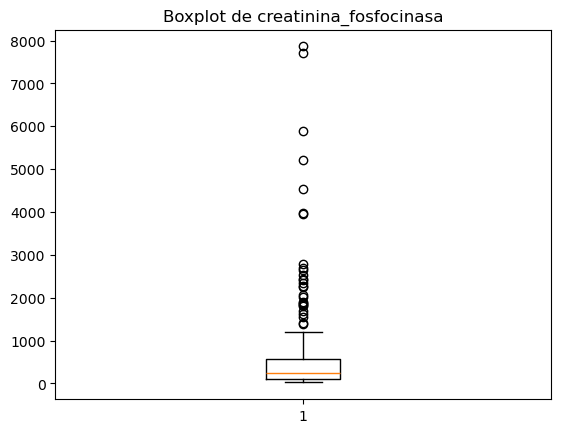

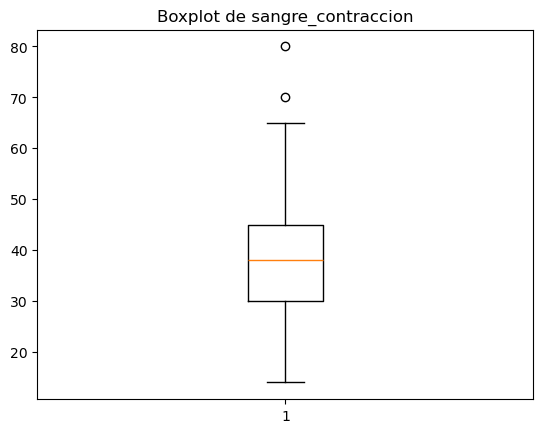

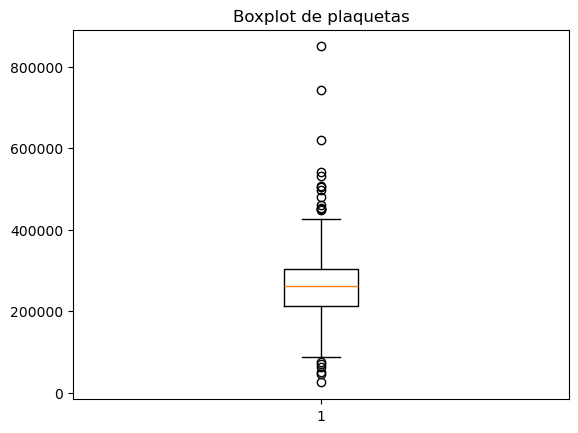

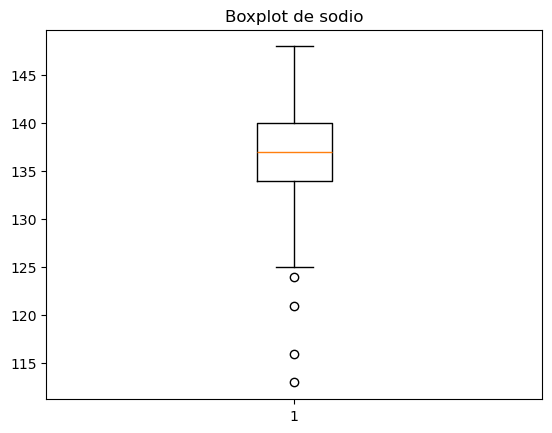

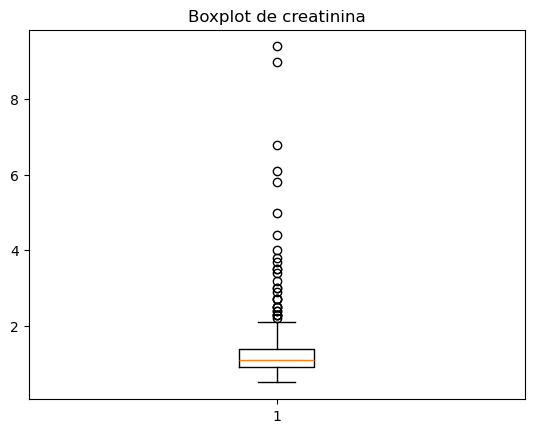

In [15]:
import matplotlib.pyplot as plt

continuos = ["creatinina_fosfocinasa", "sangre_contraccion", "plaquetas", "sodio", "creatinina"]
#Buscamos outliers en las columnas
for c in continuos:
    bp = plt.boxplot(df[c])
    
    plt.title(f"Boxplot de {c}")
    plt.show()

creatinina_fosfocinasa -> Antes: 28 | Después: 0


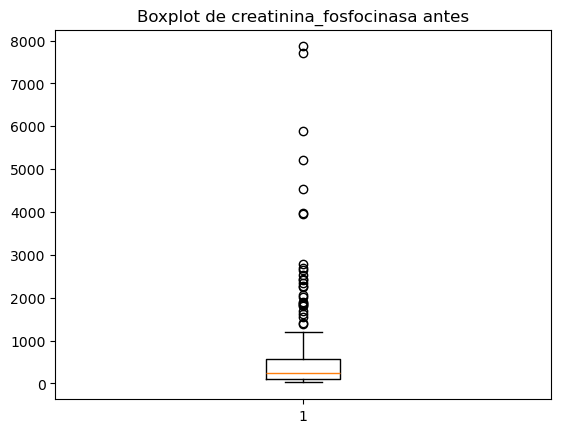

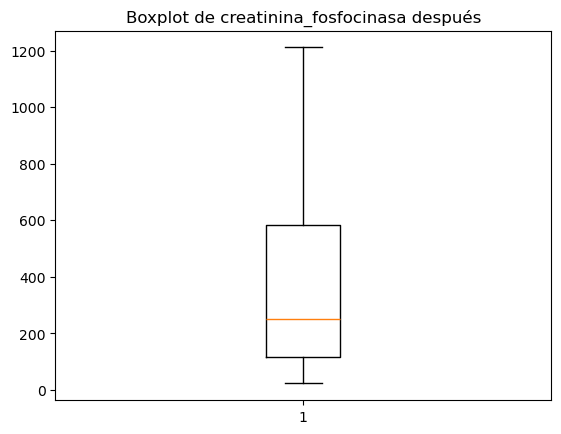

sangre_contraccion -> Antes: 2 | Después: 0


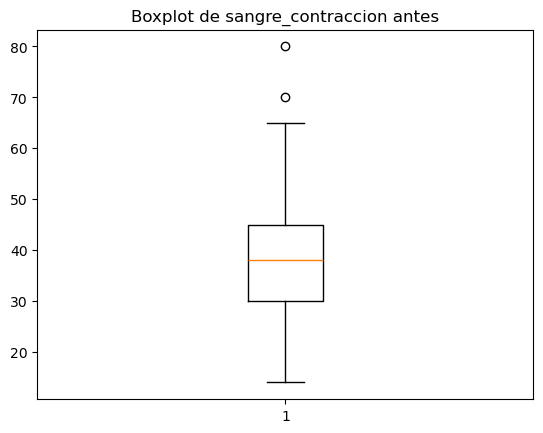

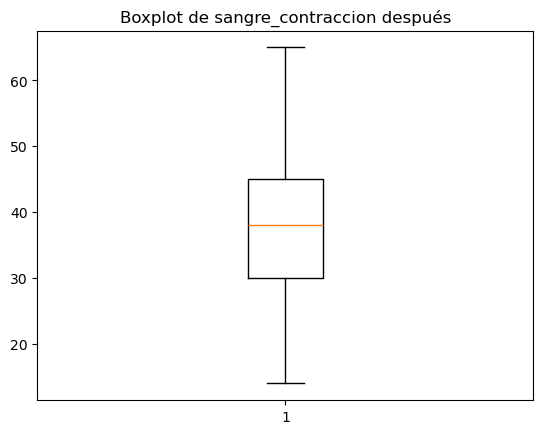

plaquetas -> Antes: 20 | Después: 0


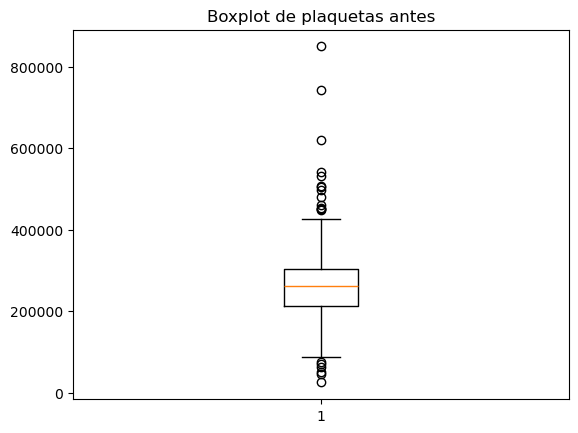

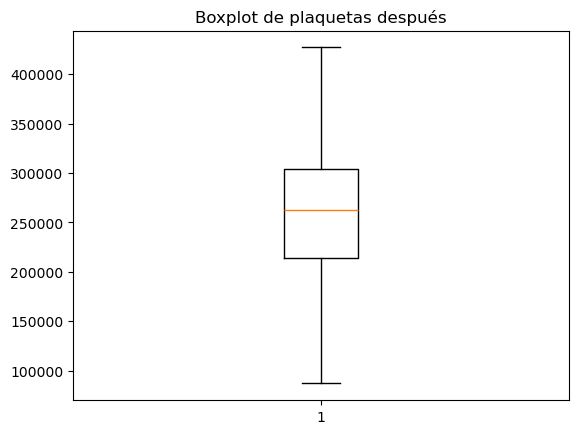

sodio -> Antes: 4 | Después: 0


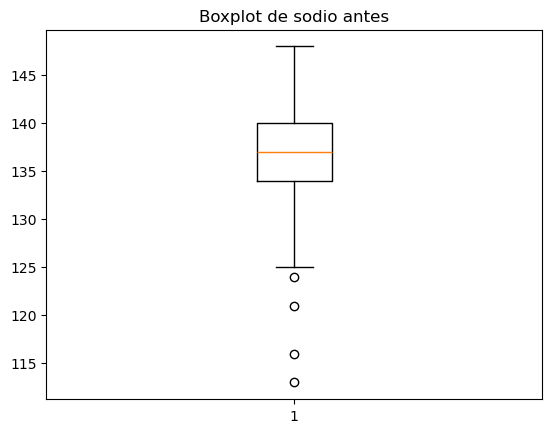

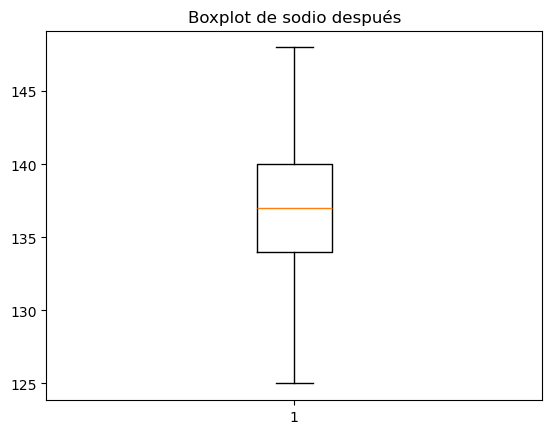

creatinina -> Antes: 29 | Después: 0


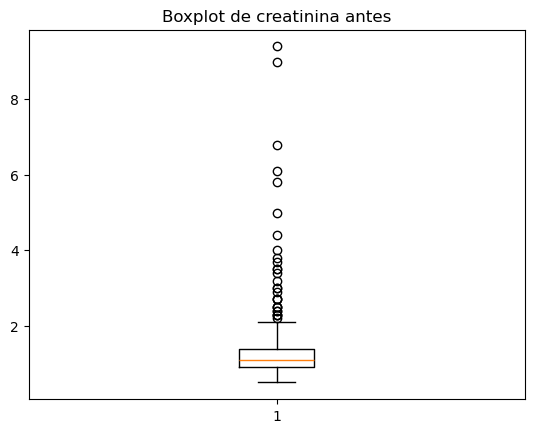

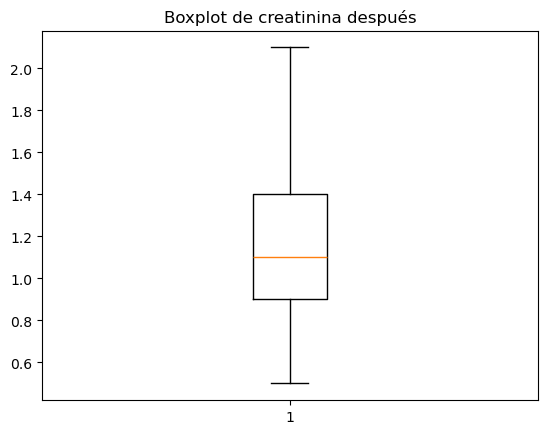

In [16]:
#Recortamos
for c in continuos:
    
    plt.figure()
    bp = plt.boxplot(df[c])
    
    # Antes
    outliers_ant = bp["fliers"][0].get_ydata()
    valor_min = bp["caps"][0].get_ydata()[0]
    valor_max = bp["caps"][1].get_ydata()[0]
    
    # Aplicamos filtro 
    df.loc[df[c] > valor_max, c] = valor_max
    df.loc[df[c] < valor_min, c] = valor_min
    plt.title(f"Boxplot de {c} antes")
    
    # Después
    plt.figure()
    bp = plt.boxplot(df[c])
    outliers_desp = bp["fliers"][0].get_ydata()
    
    print(f"{c} -> Antes: {len(outliers_ant)} | Después: {len(outliers_desp)}")
    
    plt.title(f"Boxplot de {c} después")
    plt.show()

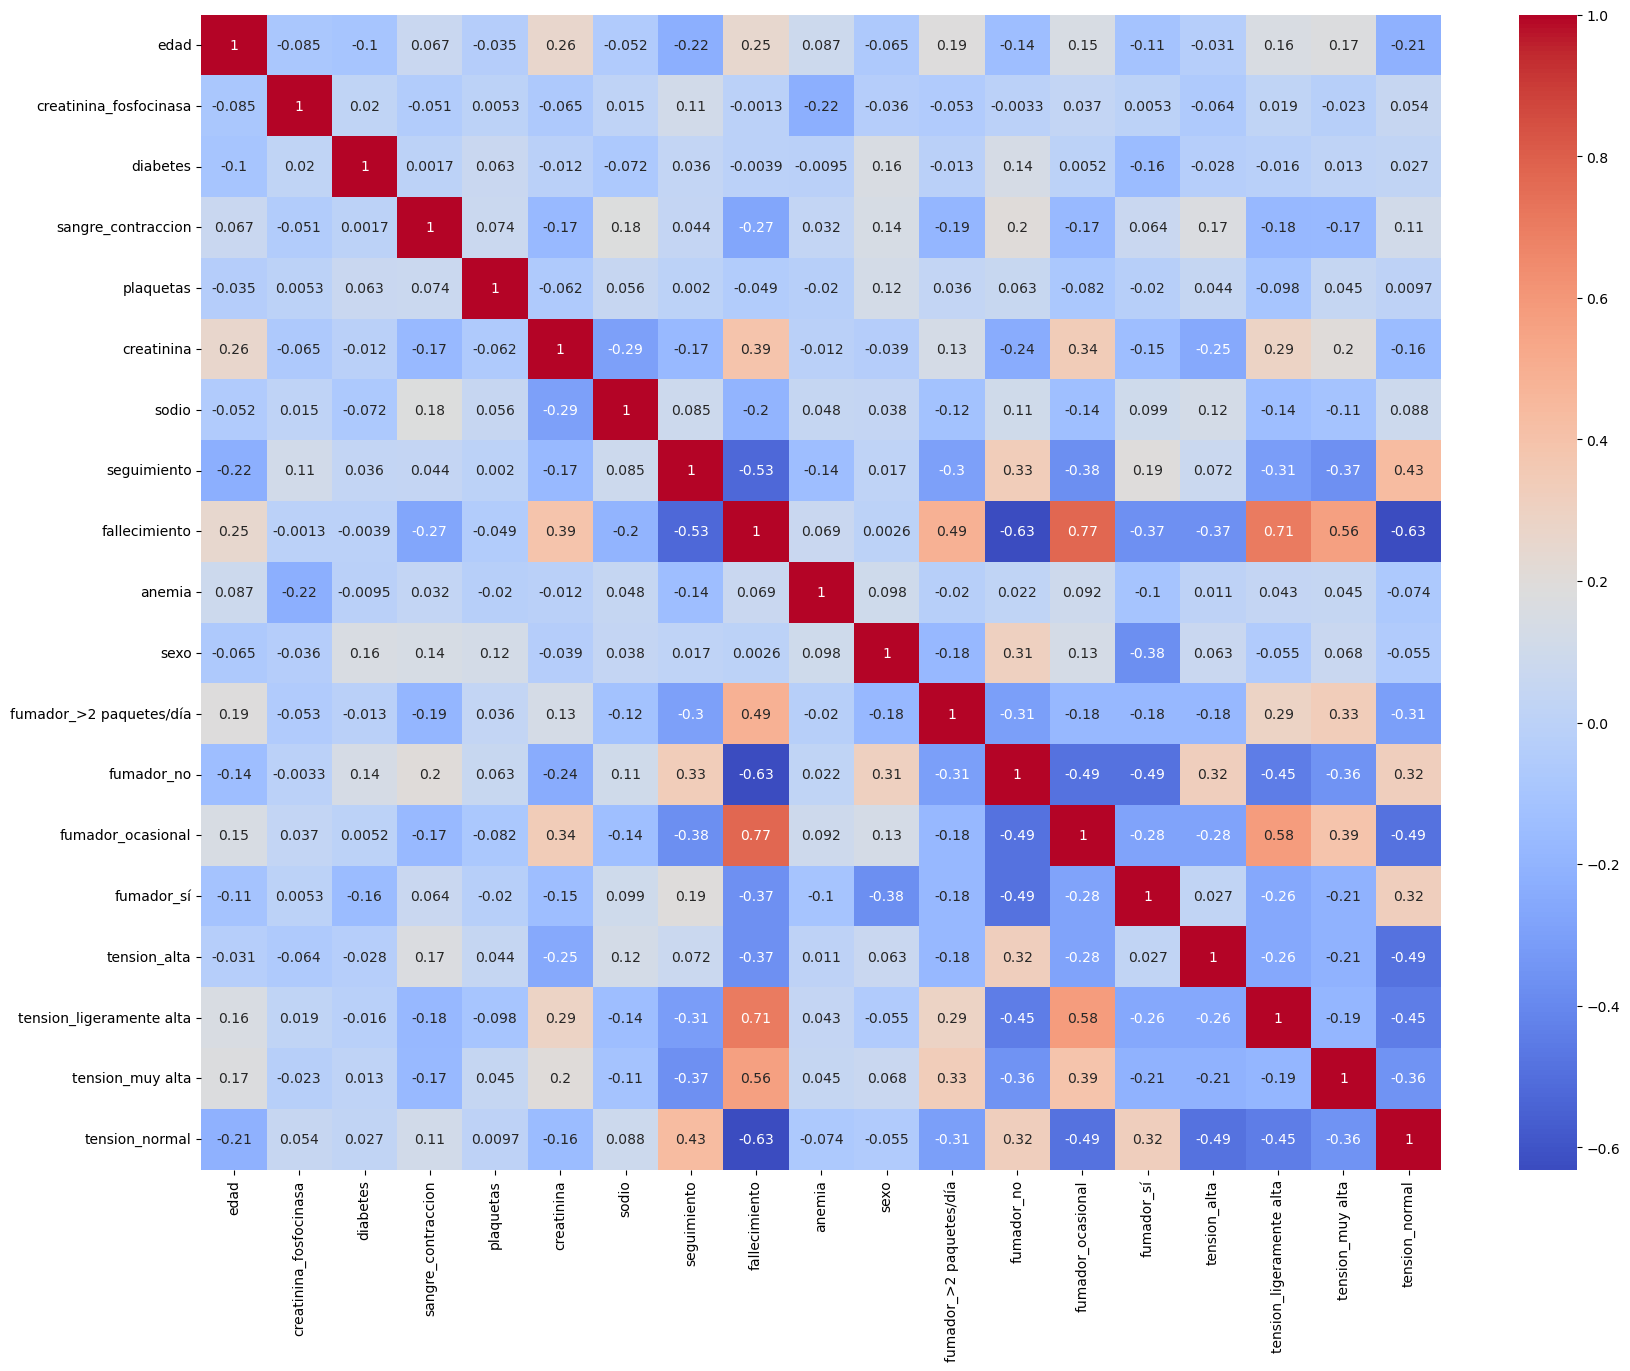

In [17]:
# Realizamos la correlación
import seaborn as sns

#Correlación
matriz = df.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(matriz, cmap="coolwarm", annot=True)
plt.show()

In [18]:
df

,edad,creatinina_fosfocinasa,diabetes,sangre_contraccion,plaquetas,creatinina,sodio,seguimiento,fallecimiento,anemia,sexo,fumador_>2 paquetes/día,fumador_no,fumador_ocasional,fumador_sí,tension_alta,tension_ligeramente alta,tension_muy alta,tension_normal
0,75,582,0,20,265000.00,1.9,130,4,1,0.0,0,0,0,1,0,0,0,1,0
1,55,1211,0,38,263358.03,1.1,136,6,1,0.0,0,0,0,1,0,0,1,0,0
2,65,146,0,20,162000.00,1.3,129,7,1,0.0,0,1,0,0,0,0,1,0,0
3,50,111,0,20,210000.00,1.9,137,7,1,1.0,0,0,0,1,0,0,1,0,0
4,65,160,1,20,327000.00,2.1,125,8,1,1.0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62,61,1,38,155000.00,1.1,143,270,0,0.0,0,0,0,0,1,1,0,0,0
295,55,1211,0,38,270000.00,1.2,139,271,0,0.0,1,0,1,0,0,0,0,0,1
296,45,1211,1,60,427000.00,0.8,138,278,0,0.0,1,0,1,0,0,0,0,0,1
297,45,1211,0,38,140000.00,1.4,140,280,0,0.0,0,0,0,0,1,0,0,0,1


# Entrenamiento de la red neuronal

Realizaremos una red neuronal de clasificación.

In [19]:
from sklearn.model_selection import train_test_split

#Dividimos los datos 
X = df.drop("fallecimiento", axis=1)
y = df["fallecimiento"]

Preparamos los datos para el entrenamiento

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [21]:
#Escalamos X 
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

mms.fit(X_train)
X_train = mms.transform(X_train)
X_test = mms.transform(X_test)

In [22]:
print(X_train)

[[0.18181818 0.14055885 0.         ... 0.         0.         1.        ]
 [0.54545455 0.45808637 1.         ... 0.         1.         0.        ]
 [0.2        0.46740051 1.         ... 0.         0.         1.        ]
 ...
 [0.38181818 0.18458933 0.         ... 0.         0.         0.        ]
 [0.45454545 0.25825572 0.         ... 0.         0.         0.        ]
 [0.45454545 1.         0.         ... 0.         0.         1.        ]]


In [23]:
print(X_train.shape)
print(X_test.shape)

(208, 18)
(90, 18)


In [24]:
propiedades = len(df.columns) -1 #Resto 1 por la variable objetivo
propiedades

18

In [25]:
#Creamos la red
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

red = Sequential(name = "ecv")

#red.add(Flatten())
#Capa densa siguiendo regla de kolmogorov
red.add(Dense(propiedades*2, activation="relu", input_shape=(propiedades,)))
#Capa de salida
red.add(Dense(1, activation="sigmoid"))

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
red.summary()

Model: "ecv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 36)             │           684 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            37 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721 (2.82 KB)

 Trainable params: 721 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#Compilamos
red.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"] )

In [28]:
h = red.fit(X_train, y_train,
        epochs=50,
        batch_size=32,
        verbose=False,
        validation_data = (X_test,y_test))

In [29]:
red.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0107


[0.010740705765783787, 1.0]

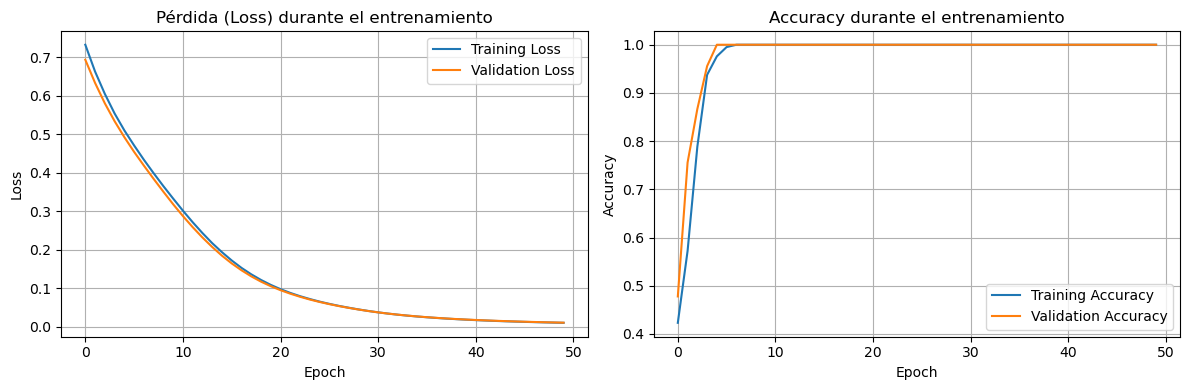

In [30]:
# Representar el histórico de entrenamiento
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(h.history['loss'], label='Training Loss')
plt.plot(h.history['val_loss'], label='Validation Loss')
plt.title('Pérdida (Loss) durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# MAE
plt.subplot(1, 2, 2)
plt.plot(h.history['accuracy'], label='Training Accuracy')
plt.plot(h.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


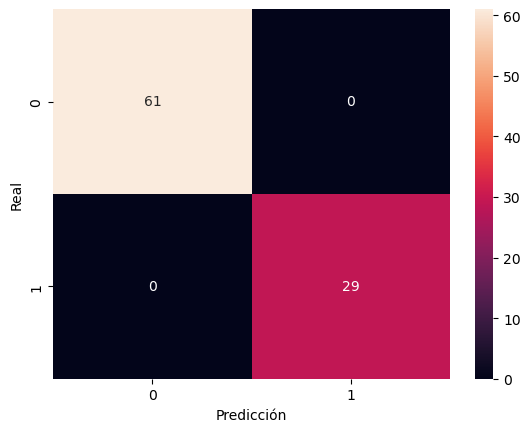

In [31]:
y_pred_prob = red.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()